# About:

Script used to validate trained CAM policy:
    
    + Plot action distribution 
    + Extract shapley values
    



In [1]:

# Standard Library Imports
import os
import sys
import pickle
import shutil

# Third Party Library Imports
import numpy as np
import torch
import pandas as pd
import torch as T
import shap
import matplotlib.pyplot as plt
import dill
from IPython.display import display, Javascript


# Local Imports 
from leo_gym.gyms.cam_gym import CamEnv, CamEnvConfig
from leo_gym.orbit.dynamics.dynamics import DynamicsConfig
from leo_gym.satellite.sat_debris_cluster import SatDebrisClusterConfig
from leo_gym.utils.utils import seed_all, create_dir
from leo_gym.rl_algorithms.h_ppo.h_ppo_agent import Agent
from leo_gym.rl_algorithms.h_ppo.config import PPOConfig



In [ ]:
# Network Path

from pathlib import Path

path = "/home/nektaf/mlruns/707215638001269727/075f388e9ca24d6188919ebbc6bb3bb1"
timestep_save = "final"

experiment_path = Path(path)


In [3]:
# Dataset Path 

mc_csv_path = "/home/nektaf/mlruns/707215638001269727/28b948f7dd104fac9b51fd56cc2c358e/artifacts/monte_carlos/cam_Ubuntu-22_2025-12-17_12-32-25/background_data_states.csv"


In [4]:
# Save SHAP plots path 

image_save_path = experiment_path / "artifacts/models" / timestep_save/ "shap"
os.makedirs(image_save_path, exist_ok=True)
os.chdir(image_save_path)


In [5]:
import json, numpy as np, re


env_cfg = experiment_path / "artifacts/env_cfg.json"


def make_env():
    seed = np.random.randint(0, 2**32)
    return CamEnv(env_cfg, seed)

num_envs = 1
env = make_env()
obs = env.reset()


In [ ]:
# Load Agent 
device = 'cuda:3'


from leo_gym.rl_algorithms.h_ppo.h_ppo_agent import Agent

policy_file_path = experiment_path / "artifacts/models" / timestep_save / "policynet.pth"
critic_file_path = experiment_path / "artifacts/models" / timestep_save / "valuenet.pth"
ppo_config = experiment_path / "artifacts/ppo_cfg.json"

ppo = Agent(
    env_obs=env.observation_space,
    env_actions=env.action_space,
    ppo_cfg=ppo_config,
    train=False,
    policy_file_path=policy_file_path,
    critic_file_path=critic_file_path,
    device=device
)
model = ppo.policy_net


In [7]:

background_data = np.loadtxt(mc_csv_path, delimiter=",")
print(background_data)


[[ 4.61046902  2.34050111  0.18339269 ... -9.25771971  1.01423398
   0.99147476]
 [ 3.44246718  2.34050111  0.18339269 ... -9.85717039  0.9072895
   1.85714985]
 [ 1.41234159  2.34050111  0.18339269 ... -9.87787648  0.55373974
   2.08913078]
 ...
 [ 6.15001525  2.61036724  4.06004055 ...  0.          0.
   0.        ]
 [ 0.78641835  2.61036724  4.06004055 ...  0.          0.
   0.        ]
 [ 3.20039385  2.61036724  4.06004055 ...  0.          0.
   0.        ]]


In [8]:
feature_names = [r"$u_{\text{p}}$", r"$i_{\text{p}}$",  r"$\Omega_{\text{p}}$", "$a\delta\lambda$", "$a\delta e_x$", "$a\delta e_y$", r"$u_{\text{s}}$", r"$i_{\text{s}}$", r"$\Omega_{\text{s}}$", r"$\Delta t_{\text{TCA}}$","$\det\mathbf{C}$", "$l$", r"$P^{\text{max}}_{\text{c}}$ ", r"$\delta r_\zeta$", r"$\delta r_\xi$"]
# feature_names = [r"$u_{\text{p}}$", "$a\delta\lambda$", "$a\delta e_x$", "$a\delta e_y$",r"$\Delta t_{\text{TCA}}$", r"$P^{\text{max}}_{\text{c}}$ "]


output_names = [ "0", "$+f_r$","$-f_r$", r"$\Delta t_\text{del}$", r"$\Delta t_{\text{dur}}$"]
len(feature_names)

15

In [9]:
from torch import nn
import torch 

class SHAPWrapper(nn.Module):
    def __init__(self, policy_net, min_val, max_val):
        super().__init__()
        self.policy_net = policy_net
        self.register_buffer("min_val", torch.tensor(min_val, dtype=torch.float32))
        self.register_buffer("max_val", torch.tensor(max_val, dtype=torch.float32))

    def forward(self, states):
        dist_dis, dist_cont = self.policy_net(states)
        probs = (dist_dis.probs * 100.0).view(states.size(0), -1)
        cont = dist_cont.mean
        act_scale = (self.max_val - self.min_val) / 2.0
        act_bias = (self.max_val + self.min_val) / 2.0
        cont = (cont.clamp(-1, 1) * act_scale + act_bias).view(states.size(0), -1)
        return torch.cat([probs, cont], dim=1)


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
min_val = [9, 1]
max_val = [55, 41]

policy_net = model
policy_net.eval()

wrapper = SHAPWrapper(policy_net, min_val, max_val).eval().to(device)


In [10]:
import numpy as np
import torch
import shap

K = 100
n_test = 1000

background_subset = np.asarray(shap.sample(background_data, K), dtype=np.float32)
idx = np.random.choice(background_data.shape[0], n_test, replace=False)
x_test_np = np.asarray(background_data[idx], dtype=np.float32)

x_bg = torch.tensor(background_subset, dtype=torch.float32, device=device)
x_test = torch.tensor(x_test_np, dtype=torch.float32, device=device)

wrapper = wrapper.eval().to(device)

explainer = shap.DeepExplainer(wrapper, x_bg)
shap_values = explainer.shap_values(x_test, check_additivity=False)

shap_exp = shap.Explanation(
    values=shap_values,
    data=x_test.detach().cpu().numpy(),
    feature_names=feature_names
)


In [11]:
background_data.shape

(8118, 15)

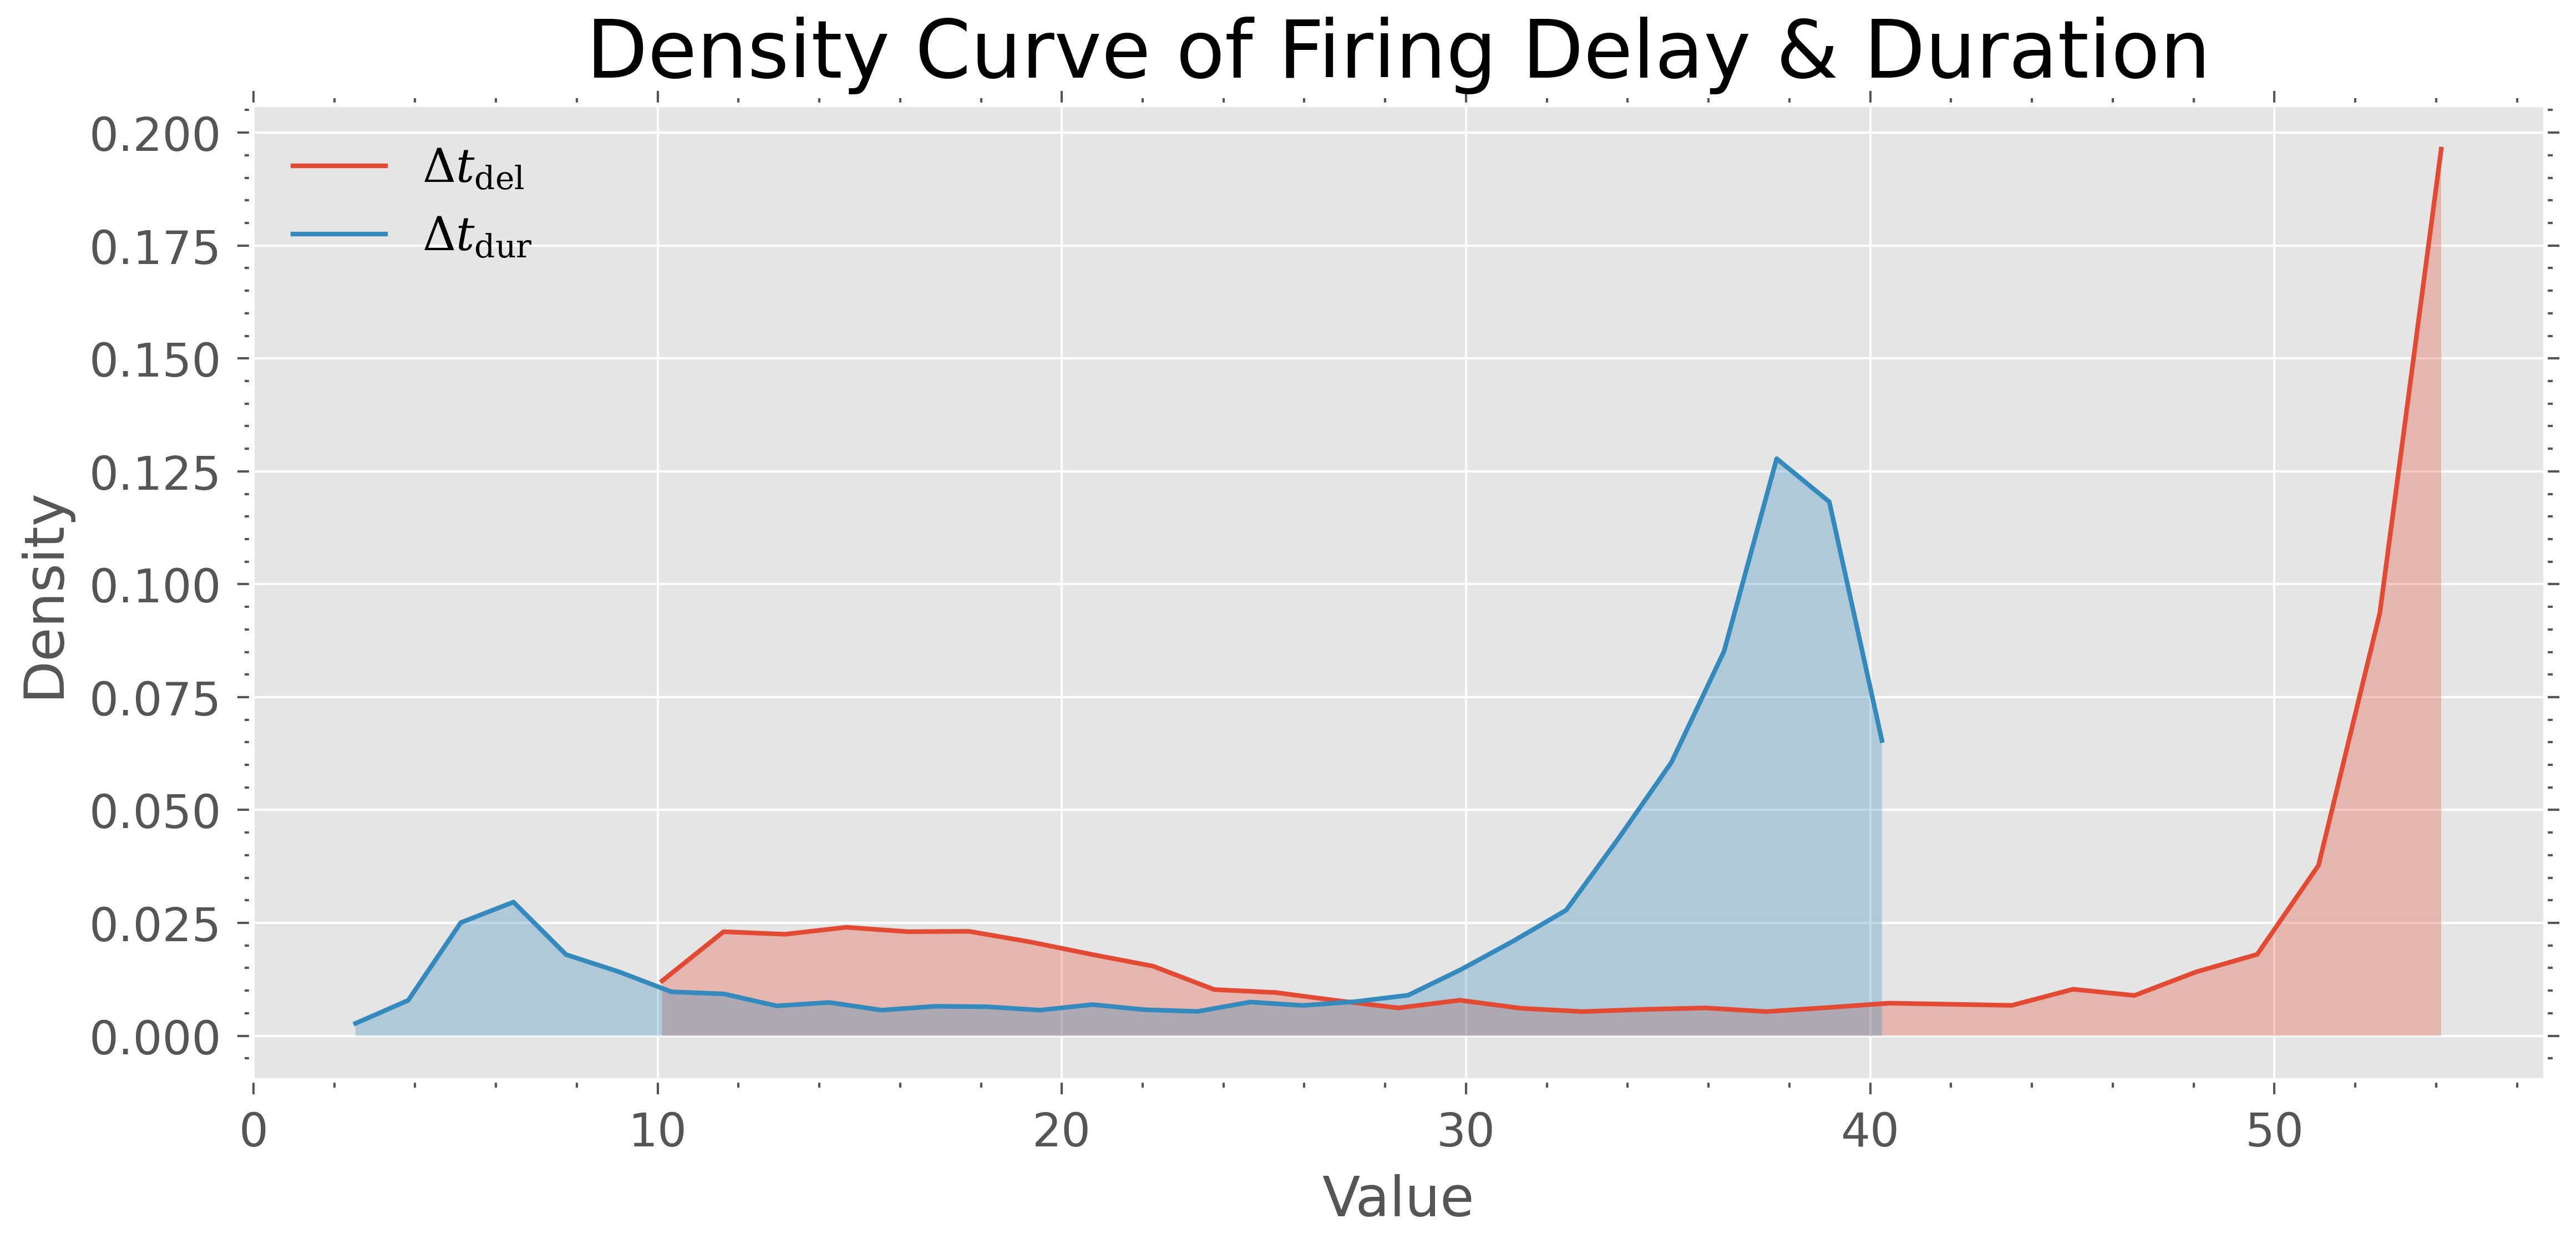

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pickle

bg_tensor = torch.tensor(background_data, dtype=torch.float32)

with torch.no_grad():
    outputs = wrapper(bg_tensor)

outputs = outputs.detach().cpu().numpy().reshape(outputs.shape[0], -1)
outputs
cont = outputs[:, 3:]  

plt.figure(figsize=(8, 4))
bins = 30

for i in range(cont.shape[1]):
    counts, edges = np.histogram(cont[:, i], bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    plt.plot(centers, counts, label=output_names[i+3])
    plt.fill_between(centers, counts, alpha=0.3)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Density Curve of Firing Delay & Duration')
plt.legend()
plt.tight_layout()
plt.savefig("cont_act_distr.png",dpi=300) 


In [13]:
outputs

array([[3.8600399e+00, 9.6139931e+01, 3.3500251e-05, 5.3415108e+01,
        2.6616461e+01],
       [4.3038960e+01, 5.6959663e+01, 1.3760936e-03, 5.3228027e+01,
        2.5109295e+01],
       [9.4772171e+01, 5.2170024e+00, 1.0827139e-02, 5.4086807e+01,
        3.4827408e+01],
       ...,
       [3.8298920e-01, 9.6982681e+01, 2.6343324e+00, 1.8600796e+01,
        6.3323174e+00],
       [1.4114021e-03, 3.2518670e-04, 9.9998260e+01, 3.7111378e+01,
        1.3075609e+01],
       [1.1085954e-02, 2.3297577e-01, 9.9755943e+01, 2.7848486e+01,
        8.7042303e+00]], dtype=float32)

In [14]:


shap_values_all = shap.Explanation(values=shap_values, 
                                    data=x_test_np,
                                    feature_names=feature_names,
                                    output_names=output_names)


In [15]:
shap_values_all.shape

(1000, 15, 5)

In [16]:

save_file_name = ["shap_f_0_summary_plot.png","shap_f_summary_plot.png","shap_f_neg_summary_plot.png","shap_dt0_summary_plot.png","shap_dtman_summary_plot.png"]
save_file_name2 = ["shap_f_0_beeswarm_plot.png","shap_f_beeswarm_plot.png","shap_f_neg_beeswarm_plot.png","shap_dt0_beeswarm_plot.png","shap_dtman_beeswarm_plot.png"]
save_file_name3 = ["shap_f_0_bar_plot.png","shap_f_bar_plot.png","shap_f_neg_bar_plot.png","shap_dt0_bar_plot.png","shap_dtman_bar_plot.png"]

for i in range(len(save_file_name)):
    print(output_names[i])
    
    ax = shap.plots.scatter(shap_values_all[:,:,output_names[i]], show=False)   
    fig = plt.gcf()
    plt.savefig(save_file_name[i],dpi=300) 
    plt.close(fig)
    
    ax = shap.plots.beeswarm(shap_values_all[:,:,output_names[i]], show=False)    
    fig = plt.gcf()
    plt.savefig(save_file_name2[i],dpi=300) 
    plt.close(fig)
    
    ax = shap.plots.bar(shap_values_all[:,:,output_names[i]], show=False)
    fig = plt.gcf()
    plt.savefig(save_file_name3[i],dpi=300) 
    plt.close(fig)
    
    

0


$+f_r$
$-f_r$
$\Delta t_\text{del}$
$\Delta t_{\text{dur}}$
